![isi_logo.png](https://media.licdn.com/dms/image/v2/D4E0BAQGVudUq4mIHXw/company-logo_200_200/company-logo_200_200/0/1722519724046/isi_markets_logo?e=2147483647&v=beta&t=ibo2GYohge2KgO-glXk3cFtZmpVm2316t8Z7fsF9kuI)


# CEIC Python package (PyCEIC) Notebook

This notebook demonstrates how to use the PyCEIC ApiClient to access and interact with CEIC’s comprehensive economic and financial data programmatically via the CEIC API.

The PyCEIC package is designed to support quant, modelling and data science workflows via a direct integration with Pandas, supporting pandas series/ dataframes as a direct output using .as_pandas()

To get started, you will need to install the official CEIC Python client package. Use the following command to install or upgrade to the latest supported version:

#The current package version via pip install:
!pip install --extra-index-url https://downloads.ceicdata.com/python ceic_api_client --upgrade

The PyCEIC package enables seamless integration with CEIC’s rich datasets, allowing you to automate data retrieval directly within your Python environment.
For assistance, please contact CEIC's Support team at helpdesk@ceicdata.com

In [ ]:
# !pip install --extra-index-url https://downloads.ceicdata.com/python ceic_api_client --upgrade

Looking in indexes: https://pypi.org/simple, https://downloads.ceicdata.com/python


In [ ]:
#%!pip freeze

aiobotocore @ file:///C:/b/abs_1c1a_vjay2/croot/aiobotocore_1682537737724/work
aiofiles @ file:///C:/b/abs_9ex6mi6b56/croot/aiofiles_1683773603390/work
aiohttp @ file:///C:/b/abs_b78zt6vo64/croot/aiohttp_1694181126607/work
aioitertools @ file:///tmp/build/80754af9/aioitertools_1607109665762/work
aiosignal @ file:///tmp/build/80754af9/aiosignal_1637843061372/work
aiosqlite @ file:///C:/b/abs_9djc_0pyi3/croot/aiosqlite_1683773915844/work
alabaster @ file:///home/ktietz/src/ci/alabaster_1611921544520/work
anaconda-anon-usage @ file:///C:/b/abs_f4tsjyl9va/croot/anaconda-anon-usage_1695310457827/work
anaconda-catalogs @ file:///C:/b/abs_8btyy0o8s8/croot/anaconda-catalogs_1685727315626/work
anaconda-client @ file:///C:/b/abs_80wttmgui4/croot/anaconda-client_1694625288614/work
anaconda-cloud-auth @ file:///C:/b/abs_5cjpnu6wjb/croot/anaconda-cloud-auth_1694462130037/work
anaconda-navigator @ file:///C:/b/abs_9f2138uoak/croot/anaconda-navigator_1699975649743/work
anaconda-project @ file:///C:/c

In [2]:
## Login function to create a session
from ceic_api_client.pyceic import Ceic
import pandas as pd
#Log in function
username = 'useremail@email.com'
password = 'userpassword'

#Ceic.login(username,password)

C:\Users\emitrov\AppData\Local\anaconda3_1\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
# The package also supports an alternative access via a Token. The token is generated in the API Dev portal - Dashboard section. 

token = "3uIKmgVbVQGAcBCyNYz5HtbzEDxo2TPAlf6YacC2Ks8LFeRonhEPXWznHXozOoOYFKW21sjGrNgYaJBwC510CdDbJkw7U9Naxt3CJgZlXL00THYeeeOPrj1ZkNwnq8PX"
Ceic.set_token(token)

#The Access is active until the user closes the Python IDE or the corresponding script

## Use the CEIC Search method to search for series

### Example search for Chinese Quarterly GDP updated after 2020

In [13]:
search_results = Ceic.search(
    keyword='GDP',
    frequency=['Q'],
    geo=[0], #Use Ceic.geo() dictionary to query for specific geo (country) codes
    
    updated_after='2020-01-01',
    limit=15, #Put limits of the results, up to 100. Use offset to paginate through results,
    key_only='TRUE',
    order='popular',
    direction='desc'
)

#print results (Series ID, Series Name, Series Frequency)

for result in search_results:
    for item in result.data.items:
        entity_id = item.metadata.id
        name = item.metadata.name
        frequency = item.metadata.frequency.name
        print(f"ID: {entity_id}, Name: {name}, Frequency: {frequency}")

ID: 369703417, Name: GDP, Frequency: Quarterly
ID: 310921001, Name: CN: GDP Index: QoQ: SA, Frequency: Quarterly
ID: 462183527, Name: GDP: 2020p, Frequency: Quarterly
ID: 397519087, Name: CN: BoP: CA: Goods: Credit (Export), Frequency: Quarterly
ID: 397519117, Name: CN: BoP: CA: Services: Credit (Export), Frequency: Quarterly
ID: 397519127, Name: CN: BoP: CA: Services: Debit (Import), Frequency: Quarterly
ID: 397519097, Name: CN: BoP: CA: Goods: Debit (Import), Frequency: Quarterly
ID: 2113401, Name: Gross Domestic Product: ytd: Total, Frequency: Quarterly
ID: 369703857, Name: GDP: TI: Real Estate, Frequency: Quarterly
ID: 369703797, Name: GDP: SI: Construction, Frequency: Quarterly
ID: 369703787, Name: GDP: SI: Industry, Frequency: Quarterly
ID: 519770547, Name: CN: GDP: Constant Price, Frequency: Quarterly
ID: 385783747, Name: GDP: SI: Industry: Manufacturing, Frequency: Quarterly
ID: 369703847, Name: GDP: TI: Financial Intermediation, Frequency: Quarterly
ID: 369703837, Name: GDP: T

### Access the data in a Pandas Dataframe directly via PyCEIC

In [4]:
search_results.as_pandas()

,id,name,indicators,unit,country,frequency,last_value,observations,key_series,layout
0,369703417,测试翻译-GDP,"Gross Domestic Product, Nominal GDP, Gross Dom...",RMB bn,China,Quarterly,37372.616350,132,True,Global Database (SR136012947); Global Database...
1,310921001,CN: GDP Index: QoQ: SA,"Gross Domestic Product, Real GDP, Real GDP Hea...",Prev Qtr=100,China,Quarterly,101.600000,57,True,China Premium Database (SR4824570)
2,462183527,GDP: 2020p,"Gross Domestic Product, Real GDP, Real GDP Hea...",RMB bn,China,Quarterly,35850.730000,16,True,Global Database (SR168147627); Global Key Seri...
3,2113401,Gross Domestic Product: ytd: Total,"Gross Domestic Product, Nominal GDP, Gross Dom...",RMB bn,China,Quarterly,134908.354628,133,True,Global Database (SR495594); Global Key Series ...
4,369703857,GDP: TI: Real Estate,"Gross Domestic Product, GDP by Industry/Gross ...",RMB bn,China,Quarterly,2218.481607,132,True,Global Database (SR136013117); Global Key Seri...
5,369703797,GDP: SI: Construction,"Gross Domestic Product, GDP by Industry/Gross ...",RMB bn,China,Quarterly,2834.634471,132,True,Global Database (SR136012987); Global Key Seri...
6,369703787,GDP: SI: Industry test,"Gross Domestic Product, GDP by Industry/Gross ...",RMB bn,China,Quarterly,10825.961140,132,True,Global Database (SR136013087); Global Key Seri...
7,385783747,GDP: SI: Industry: Manufacturing,"Gross Domestic Product, GDP by Industry/Gross ...",RMB bn,China,Quarterly,8982.493995,40,True,Global Database (SR136012967); Global Key Seri...
8,369703827,GDP: TI: Wholesale and Retail Trade,"Gross Domestic Product, GDP by Industry/Gross ...",RMB bn,China,Quarterly,3833.664722,132,True,Global Database (SR136012997); Global Key Seri...
9,369703837,GDP: TI: Accommodation and Catering Trade,"Gross Domestic Product, GDP by Industry/Gross ...",RMB bn,China,Quarterly,734.514334,132,True,Global Database (SR136013007); Global Key Seri...


In [11]:
#Reverse the order of the DF with Pandas function "transpose"
search_results.as_pandas().pivot(index='name', columns='frequency',values='id')


frequency,Quarterly
name,
CN: GDP Index: QoQ: SA,310921001
CN: GDP: Constant Price,519770547
GDP: 2020p,462183527
GDP: SI: Construction,369703797
GDP: SI: Industry test,369703787
GDP: SI: Industry: Manufacturing,385783747
GDP: TI: Accommodation and Catering Trade,369703837
GDP: TI: Financial Intermediation,369703847
"GDP: TI: Information Transmission, Software and IT Service",385783757


### Use Geo Info Dictionary to find the codes for particular geographies

In [74]:
countries_result = Ceic.geo()
countries = countries_result.data
codes = {'US', 'UK', 'CN', 'IN'}
filtered = [c for c in countries if c.iso_code in codes]

for c in filtered:
    print(f'"Code: {c.id}": "Country: {c.title}"')

"Code: 0": "Country: China"
"Code: 2916": "Country: United Kingdom"
"Code: 2979": "Country: India"
"Code: 3100": "Country: United States"


In [75]:
## Use a dictionary in a Pandas Dataframe format

Ceic.frequencies().as_pandas()

,id,name
0,D,DAILY
1,W,WEEKLY
2,M,MONTHLY
3,Q,QUARTERLY
4,H,SEMIANNUALLY
5,Y,YEARLY
6,V,TRIENNIAL
7,Z,QUINQUENNIALLY
8,T,DECADAL


## Access series information for specific series IDs
#### Both Ceic.series() and Ceic.series_data() returns timepoints
#### Ceic.series_metadata() can be used to extract metadata information only
#### Access the data in a dataframe directly
#### The methods support multiple comma-separated series within one single API call

In [77]:
# Access series Metadata

Ceic.series_metadata(['210438802', '370007807']).as_pandas()

,id,name,indicators,indicator,classification,unit,country,frequency,status,source,...,time_points_last_update_time,key_series,new_series,period_end,last_value,last_change,number_of_observations,has_continuous_series,trade_code,replacement
0,370007807,Bangladesh Bank: Liabilities: Agricultural Cre...,"Banking Sector, Loans, Bank Loans/Claims (by S...",Balance Sheets,Banking Sector,BDT mn,Bangladesh,Weekly,Active,Bangladesh Bank,...,2025-04-08 09:05:33+00:00,False,False,4,7600.0,None,480,False,None,None
1,210438802,HICP: EA: YoY,,Harmonised Consumer Prices,Inflation,%,European Union,Monthly,Active,Eurostat,...,2025-02-03 10:10:45+00:00,True,False,31,2.5,None,337,False,None,None


In [78]:
# Get series Timepoints
# When querying multiple series, the package returns a tidy (long) format with all queried data

timepoints_df = Ceic.series(["249097301", "356927477", "208819402", "414282657", "211396102","413256477","408948807"], count = 20).as_pandas()

timepoints_df


,last_update_date,value,date,id
0,2025-04-04,2.821549,2025-02-01,414282657
1,2025-02-25,1.906561,2025-01-01,413256477
2,2025-02-25,1.319766,2025-01-01,356927477
3,2025-02-24,2.806383,2025-01-01,211396102
4,2025-02-12,3.000483,2025-01-01,414282657
...,...,...,...,...
135,2021-04-12,4.867158,2021-03-01,408948807
136,2021-01-12,6.364859,2020-12-01,408948807
137,2020-11-12,6.896552,2020-09-01,408948807
138,2020-08-13,6.571227,2020-06-01,408948807


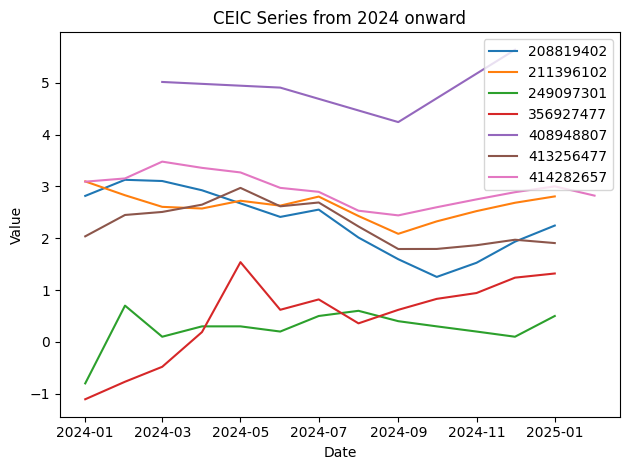

In [79]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert 'date' column to pandas datetime
timepoints_df['date'] = pd.to_datetime(timepoints_df['date'])

# Filter dataframe for dates from 2024-01-01 onward
df_filtered = timepoints_df[timepoints_df['date'] >= pd.Timestamp('2024-01-01')]

for series_id, group in df_filtered.groupby('id'):
    plt.plot(group['date'], group['value'], label=str(series_id))

plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('CEIC Series from 2024 onward')
plt.tight_layout()
plt.show()


### The package also supports usage of CDMNext created Insights

In [28]:
insights = Ceic.search_insights(order="edit_date", direction="desc")

count = 0
for insight in insights:
    for item in insight.data.items:
        print(f"Insight_ID: {item.id}, Insight_Name: {item.name}")
        count += 1
        if count >= 10:
            break
    if count >= 10:
        break

Insight_ID: 91429807-b693-41a7-b793-74ce9e63141f, Insight_Name: Indonesian inflation: the predictive power of daily food price data_copy
Insight_ID: ad270c41-6c2b-44cf-95bb-25d0c930d3fa, Insight_Name: test new today
Insight_ID: 6f85d462-8b36-459a-b664-6802608b3515, Insight_Name: Insight 245
Insight_ID: d7c950ac-5f68-41e3-92dc-87309667e259, Insight_Name: save 2121212
Insight_ID: f20e1354-e52c-47b5-8e8a-2d64b01c6b5e, Insight_Name: test conti series
Insight_ID: b2d8a31f-0219-4ee3-a80d-a41d5092c2cd, Insight_Name: daily series for Eva Wang - eviews
Insight_ID: 2e02f76f-0ce7-4563-a6e2-3082024556d2, Insight_Name: tezt Arima
Insight_ID: 6f4635b4-a981-4acf-bc1b-b45edaaf7b76, Insight_Name: Insight 241
Insight_ID: 05b455ad-1718-4fe9-8753-2a56eef6fb41, Insight_Name: Global Commodity Price Indices_copy
Insight_ID: 212b1372-4557-421f-8704-90f1140c4747, Insight_Name: China GDP Nowcast_Propri


In [24]:
#Paginate search or get more than 100 series:
##1. Check what is the total number of
ceic_search = Ceic.search("US non farm paryoll", frequency = ["M"], status = ["T", "C", "B"], order = "popular", direction = "desc", lang = "en",offset="100",limit=100).as_pandas()

#Access the full attrs dictionary
print(ceic_search.attrs)

# Get the batch size
batch_size = ceic_search.attrs['batch_size']
print("Batch size:", batch_size)

# Get the total available results
total = ceic_search.attrs['total']
print("Total results:", total)


In [ ]:
import pandas as pd
import time

batch_size = ceic_search.attrs['batch_size']
total = ceic_search.attrs['total']

all_results = []
offset = 0

while offset < total:
    page_df = Ceic.search(
        keyword="Marine port",
        frequency=["D"],
        status=["T", "C", "B"],
        order="popular",
        direction="desc",
        country=["BN"],
        lang="en",
        offset=offset,
        limit=batch_size
    ).as_pandas()

    start = offset
    end = min(offset + batch_size - 1, total - 1)
    print(f"Search results from {start} to {end}")

    all_results.append(page_df)
    offset += batch_size

    time.sleep(0.3)

print("Pagination loop complete.")
df_all = pd.concat(all_results, ignore_index=True)
print(f"Total number of series loaded into the dataframe: {len(df_all)}")


In [40]:
## Access Release calendar via Python:
#Returns 'releases code' that has the full details
Ceic.releases(keyword = "UK GDP",release_date_from = '2024-01-01', release_date_to = '2025-12-31', release_status = ["Released","Pending"]).as_pandas()


,code,time_point_date,release_date,period_start,period_end,release_type,release_status
0,10000758,2025-11-01,None,2025-12-22,2025-12-31,Final,Pending
1,50052457,2025-09-01,None,2025-12-22,2025-12-22,Final,Pending
2,50034037,2025-09-01,None,2025-12-22,2025-12-22,Final,Pending
3,50066037,2025-09-01,None,2025-12-22,2025-12-22,Final,Pending
4,10006346,2025-10-01,None,2025-12-12,2025-12-12,Final,Pending
...,...,...,...,...,...,...,...
95,50034037,2024-09-01,2024-12-23,2024-12-24,2024-12-31,Final,Released
96,50052457,2024-09-01,2024-12-23,2024-12-16,2024-12-30,Final,Released
97,10000758,2024-11-01,2024-12-20,2024-12-16,2024-12-27,Final,Released
98,50042607,2024-09-01,2024-12-13,2024-12-04,2024-12-10,Final,Released


In [19]:
#Load specific "releases code" to get full details about the release - what series IDs are expected to get update, what is the series ID name, Source Name, data Frequency, etc. 
Ceic.release_series("357635947").as_pandas()

""


In [ ]:
#Load releases information searching by series ID:
Ceic.series_releases(["365383817"]).as_pandas()

## PyCEIC support Point-in-time endpoints & access to vintages

In [82]:
Ceic.series_vintages("532539937").as_pandas()

,revision_date,vintage_value,date,id
0,2025-03-07T05:06:46.000Z,3487.0,2025-02-28,532539937
1,2025-03-07T05:06:46.000Z,3491.0,2025-02-27,532539937
2,2025-02-05T08:41:16.000Z,3513.0,2025-02-05,532539937
3,2025-01-27T06:22:00.000Z,3505.0,2025-01-27,532539937
4,2025-01-26T09:22:00.000Z,3505.0,2025-01-26,532539937
...,...,...,...,...
349,2024-09-30T03:00:00.000Z,3834.0,2023-09-12,532539937
350,2024-09-30T03:00:00.000Z,3818.0,2023-09-11,532539937
351,2024-09-30T03:00:00.000Z,3827.0,2023-09-08,532539937
352,2024-09-30T03:00:00.000Z,3846.0,2023-09-07,532539937


## PyCEIC support workflows around identifying Replacement series & automatically prolonging historical data via linked continuous series

In [83]:
#Example: China Steel Production (Bar) has been Discontinued by the source. The PYCEIC package allows users to identify automatically the direct replacement new series

cn_steel = (Ceic.series_metadata("12988901")).as_pandas()

name = cn_steel["name"]
status = cn_steel["status"]
replacement = cn_steel["replacement"]
replacement_ids = replacement.ids

print(f"Name: {name}\nStatus: {status}\nReplacement IDs: {', '.join(replacement_ids) if replacement_ids else 'None'}")

Name: (DC)Steel: Production: SP: Bar
Status: Discontinued
Replacement IDs: 3614501


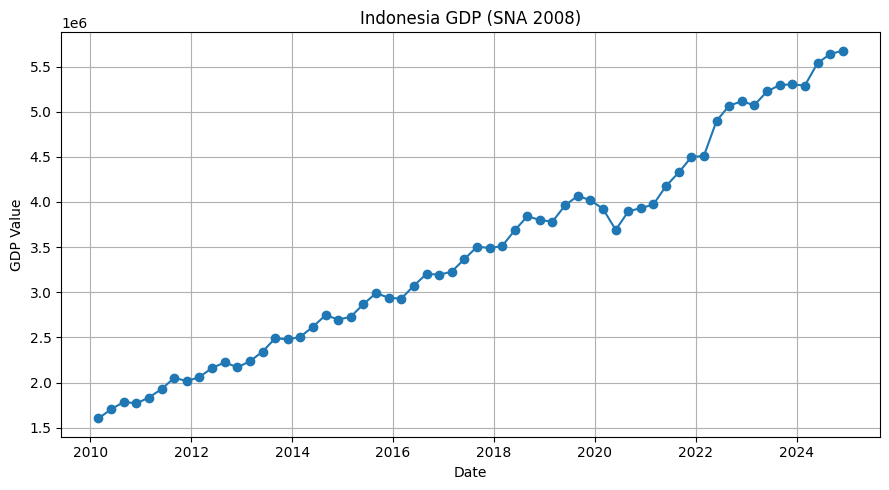

In [84]:
## Splicing historical data example: Indonesia's GDP under SNA 2008 methodology is having history only back to 2010

indonesia_GDP = Ceic.series("365749327").as_pandas()

import matplotlib.pyplot as plt
import pandas as pd

# Convert date column to datetime
indonesia_GDP["date"] = pd.to_datetime(indonesia_GDP["date"])

# Plot GDP over time
plt.figure(figsize=(9,5))
plt.plot(indonesia_GDP["date"], indonesia_GDP["value"], marker="o", linestyle="-")

plt.title("Indonesia GDP (SNA 2008)")
plt.xlabel("Date")
plt.ylabel("GDP Value")
plt.grid(True)
plt.tight_layout()
plt.show()


## Using the 'With_historical_extension = TRUE', the package can automatically prolong data with identified rebased series with a single parameter

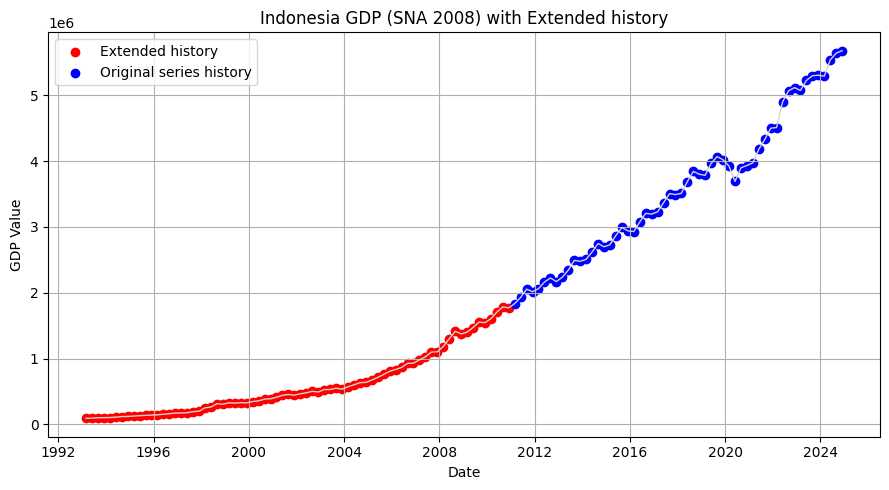

In [89]:
# Extend and prepare data
indonesia_GDP_extended = Ceic.series("365749327", with_historical_extension='TRUE').as_pandas()
indonesia_GDP_extended["date"] = pd.to_datetime(indonesia_GDP_extended["date"])

# Split into two groups: <=2010 and >2010
mask_pre2010 = indonesia_GDP_extended["date"].dt.year <= 2010
mask_post2010 = ~mask_pre2010

# Plot
plt.figure(figsize=(9,5))

# Base line for continuity
plt.plot(indonesia_GDP_extended["date"], indonesia_GDP_extended["value"], color="lightgray", linewidth=1)

# Red points for <=2010
plt.scatter(indonesia_GDP_extended.loc[mask_pre2010, "date"],
            indonesia_GDP_extended.loc[mask_pre2010, "value"],
            color="red", label="Extended history")

# Blue points for >2010
plt.scatter(indonesia_GDP_extended.loc[mask_post2010, "date"],
            indonesia_GDP_extended.loc[mask_post2010, "value"],
            color="blue", label="Original series history")

plt.title("Indonesia GDP (SNA 2008) with Extended history")
plt.xlabel("Date")
plt.ylabel("GDP Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


This next example is a simple script that can be put in Power BI thus enabling direct raw data extraction from CEIC. 

In [32]:
#First - initiate PyCEIC and authenticate via your API token:
from ceic_api_client.pyceic import Ceic
import pandas as pd
token = "paste_your_token_as_string_here"
Ceic.set_token(token)

#Use a selected series Id to create the df for timepoints data and for metadata. Then further merge the two:
df_1 = Ceic.series('94583907').as_pandas()
df_2 = Ceic.series_metadata('94583907').as_pandas()

#convert the "id" to integers in both data frames:
df_1['id'] = df_1['id'].astype(int)
df_2['id'] = df_2['id'].astype(int)

#Merge the two data frames on the "id" column and with "outer" approach:
merged_df = pd.merge(df_2, df_1, on='id', how='outer')
print(merged_df)

           id                            name  \
0    94583907  Consumer Price Index: 1995=100   
1    94583907  Consumer Price Index: 1995=100   
2    94583907  Consumer Price Index: 1995=100   
3    94583907  Consumer Price Index: 1995=100   
4    94583907  Consumer Price Index: 1995=100   
..        ...                             ...   
419  94583907  Consumer Price Index: 1995=100   
420  94583907  Consumer Price Index: 1995=100   
421  94583907  Consumer Price Index: 1995=100   
422  94583907  Consumer Price Index: 1995=100   
423  94583907  Consumer Price Index: 1995=100   

                                   indicators        indicator classification  \
0    Inflation, Consumer Prices, Headline CPI  Consumer Prices      Inflation   
1    Inflation, Consumer Prices, Headline CPI  Consumer Prices      Inflation   
2    Inflation, Consumer Prices, Headline CPI  Consumer Prices      Inflation   
3    Inflation, Consumer Prices, Headline CPI  Consumer Prices      Inflation   
4    I

In [12]:
#How to call the series from the mapping file via PyCEIC


ceic_result = Ceic.series(["384044837", "384050377", "384073207", "384073217", "384236927", "384078797", "222841201", "384081957", "384082287", "384087447", "501962997", "384097487", "384097947", "414265367", "221136301", "384098117", "414265387", "377174207", "384099137", "384099217", "451122047", "294321801", "226408701", "384101777", "403403927", "221476901", "221634901", "384106817", "384113177", "384123187", "223591401", "222917301", "384143647", "384144017", "384160847", "267403402", "384166387", "414265507", "384170167", "414265527", "384176297", "402799197", "508435137", "384182537", "384182647", "384237237", "523790327", "384184317", "384184407", "384185367", "384186317", "403684477", "414265577", "384189117", "384191507", "502762597", "384191537", "384192577", "414265597", "414265607", "384194177", "384204017", "414266367", "414265637", "267411702", "384204237", "384204467", "521293847", "384204787", "384217357", "458692647", "416806917", "384217287", "481246697", "402649617"], lang = "en", blank_observations = True)
ceic_result_df = ceic_result.as_pandas()
print(ceic_result_df)


     last_update_date          value       date         id
0          2025-10-08   51365.362310 2025-12-01  384237237
1          2025-09-24  135026.807544 2025-12-01  384236927
2          2025-11-20    1550.554536 2025-09-01  384050377
3          2025-11-18   19071.933342 2025-09-01  414265367
4          2025-11-18   21669.389077 2025-09-01  384097487
...               ...            ...        ...        ...
6615              NaT            NaN 1954-12-01  222917301
6616              NaT            NaN 1953-12-01  222917301
6617              NaT            NaN 1952-12-01  222917301
6618       2024-02-13      24.400000 1951-12-01  222917301
6619       2024-02-13      13.800000 1950-12-01  222917301

[6620 rows x 4 columns]


In [14]:
ceic_result = Ceic.series(["408382787", "384044837", "384050377", "384073207", "384073217", "384236927", "384078797", "222841201", "384081957", "384082287", "384087447", "501962997", "384097487", "384097947", "414265367", "221136301", "384098117", "414265387", "377174207", "384099137", "384099217", "451122047", "294321801", "226408701", "384101777", "403403927", "221476901", "221634901", "384106817", "384113177", "384123187", "223591401", "222917301", "384143647", "384144017", "384160847", "267403402", "384166387", "414265507", "384170167", "414265527", "384176297", "402799197", "508435137", "384182537", "384182647", "384237237", "523790327", "384184317", "384184407", "384185367", "384186317", "403684477", "414265577", "384189117", "384191507", "502762597", "384191537", "384192577", "414265597", "414265607", "384194177", "384204017", "414266367", "414265637", "267411702", "384204237", "384204467", "521293847", "384204787", "384217357", "458692647", "416806917", "384217287", "481246697", "402649617"], lang = "en", blank_observations = True)
ceic_result_df = ceic_result.as_pandas()
print(ceic_result_df)

     last_update_date          value       date         id
0          2025-10-08   51365.362310 2025-12-01  384237237
1          2025-09-24  135026.807544 2025-12-01  384236927
2          2025-11-20    1550.554536 2025-09-01  384050377
3          2025-11-18   19071.933342 2025-09-01  414265367
4          2025-11-18   21669.389077 2025-09-01  384097487
...               ...            ...        ...        ...
6636              NaT            NaN 1954-12-01  222917301
6637              NaT            NaN 1953-12-01  222917301
6638              NaT            NaN 1952-12-01  222917301
6639       2024-02-13      24.400000 1951-12-01  222917301
6640       2024-02-13      13.800000 1950-12-01  222917301

[6641 rows x 4 columns]
